<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Загрузка-данных" data-toc-modified-id="Загрузка-данных-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Загрузка данных</a></span></li><li><span><a href="#Исследовательский-анализ-данных-(EDA)" data-toc-modified-id="Исследовательский-анализ-данных-(EDA)-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Исследовательский анализ данных (EDA)</a></span></li><li><span><a href="#Построение-модели-прогнозирования-оттока-клиентов" data-toc-modified-id="Построение-модели-прогнозирования-оттока-клиентов-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Построение модели прогнозирования оттока клиентов</a></span></li><li><span><a href="#Кластеризация-клиентов" data-toc-modified-id="Кластеризация-клиентов-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Кластеризация клиентов</a></span></li><li><span><a href="#Выводы-и-базовые-рекомендации-по-работе-с-клиентами" data-toc-modified-id="Выводы-и-базовые-рекомендации-по-работе-с-клиентами-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Выводы и базовые рекомендации по работе с клиентами</a></span></li></ul></div>

# Разработка стратегии взаимодействия с клиентами сети фитнес-центров

Сеть фитнес-центров разрабатывает стратегию взаимодействия с клиентами на основе аналитических данных. В нашем распоряжении имеются переведенные в электронный вид клиентские анкеты сети. Задача проекта — провести анализ и подготовить план действий по удержанию клиентов. А именно: 
1. Создать модель, позволяющую прогнозировать вероятность оттока (на уровне следующего месяца) для каждого клиента;
2. Сформировать типичные портреты клиентов: выделить несколько наиболее ярких групп и охарактеризовать их основные свойства;
3. Проанализировать основные признаки, наиболее сильно влияющие на отток;
4. Сформулировать основные выводы и разработать рекомендации по повышению качества работы с клиентами:
    - выделить целевые группы клиентов;
    - предложить меры по снижению оттока;
    - определить другие особенности взаимодействия с клиентами.

Импортируем необходимые библиотеки и зададим функцию data_check для базовой оценки данных.

In [1]:
import os
import math
import datetime as dt
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage 
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

plt.style.use('seaborn')
pd.options.display.max_colwidth = 150

In [2]:
def data_check(df):
    df.info()
    print('Проверка наличия дубликатов:', df.duplicated().sum())
    print('Проверка наличия пропусков:', df.isna().sum().sum())
    display(df.head())

## Загрузка данных

Загрузим данные в таблицу df

In [3]:
pth1 = '-/datasets/gym_churn.csv'
pth2 = 'https://-/gym_churn.csv'

if np.logical_and(os.path.exists(pth1), os.path.isfile(pth1)):
    df = pd.read_csv(pth1)
elif pth2.endswith('.csv'):
    df = pd.read_csv(pth2)
else:
    print('Файл с данными не найден')

## Исследовательский анализ данных (EDA)

Оценим имеющиеся данные и приведем их описание

In [4]:
data_check(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


Описание данных представлено в README-файле.

Имеется информация о 4 тысячах клиентов в разрезе 14 признаков (5 числовых и 9 категориальных). Все они заданы числами, текстовые, либо поля с логическим типами данных отсутствуют. Пропуски и полные дубликаты также отсутсвуют. Целевая переменная не имеет временной структуры. Для удобства дальнейшей работы с данными приведем названия столбцов к нижнему регистру.

In [5]:
df.columns = [x.lower() for x in df.columns]

Изучим распределение значений в атрибутах. Начнем с распределения бинарных признаков.

In [6]:
binary_attribute_list = []
for column in df.columns:
    if df[column].nunique() == 2:
        binary_attribute_list.append(column)

attribute_distribution = pd.DataFrame(columns=binary_attribute_list)
for attribute in binary_attribute_list:
    attribute_distribution[attribute] = df[attribute].value_counts(normalize=True, ascending=True) * 100
    
attribute_distribution

,gender,near_location,partner,promo_friends,phone,group_visits,churn
0,48.975,15.475,51.325,69.15,9.65,58.775,73.475
1,51.025,84.525,48.675,30.85,90.35,41.225,26.525


Пол и принадлежность клиента к компании-партнеру распределены практически равномерно. Близкое распределение у атрибута group_visits - однако бОльшая часть клиентов не посещала групповые занятия. Подавляющее большинство клиентов из выборки проживают в районе нахождения фитнес-центра и заполняют данные о контактном телефоне при заключении договора. Практически каждый третий клиент был привлечен промо-акцией, и каждый четвертый попал в отток.

Оставшиеся атрибуты изучим более подробно. Начнем с длительности текущего действующего абонемента.

In [7]:
df['contract_period'].value_counts(normalize=True) * 100

1     55.175
12    24.000
6     20.825
Name: contract_period, dtype: float64

Немногим более половины клиентов оформляет абонемент на 1 месяц. Если же клиент решил заниматься спортом серьезно - более вероятно, что он предпочтет оплатить абонемент сразу на 12 месяцев, таких клиентов немного больше по сравнению с теми, кто оформляет на 6 месяцев. Сразу проверим, как длительность абоненемента влияет на вероятность оттка клиента - скорее всего, чем меньше его длительность, тем выше процент оттока.

In [8]:
cp_churn = df.groupby('contract_period').agg({'churn': ['sum', 'count']})
cp_churn.columns = cp_churn.columns.to_flat_index()
cp_churn.rename(columns={('churn', 'sum'): 'percentage_of_total_churn', ('churn', 'count'):'churn_rate_group'}, inplace=True)
cp_churn['churn_rate_group'] = cp_churn['percentage_of_total_churn'] / cp_churn['churn_rate_group']
cp_churn['percentage_of_total_churn'] = cp_churn['percentage_of_total_churn'].div(df['churn'].sum())
cp_churn = round(cp_churn * 100, 2)
cp_churn

,percentage_of_total_churn,churn_rate_group
contract_period,,
1,88.03,42.32
6,9.80,12.48
12,2.17,2.40


Предположение подтвердилось - если после оплаты месячного абонемента более 40% от оформлявших не будут его продлевать, то у оплативших сразу год занятий шанс попасть в отток не дотягивает даже до 2,5%. При этом из всех пользователей ушедших в отток 88% имели месячный абонемент. Результаты выглядят правдоподобно - примая решение оплатить достаточно крупную сумму, человек более трезво оценивает свою мотивацию, а сам факт оплаты может служить дополнительным стимулом к продолжению тренировок. Перейдем к более сложному атрибуту - сроку до окончания текущего действующего абонемента.

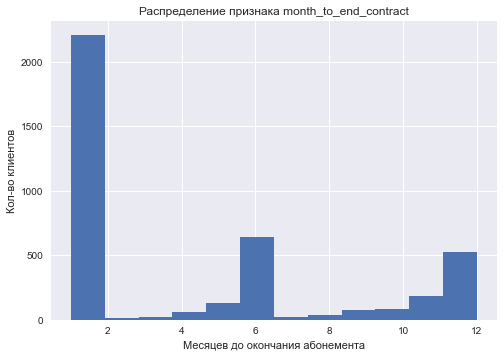

In [9]:
df['month_to_end_contract'].hist(bins=df['month_to_end_contract'].nunique())
plt.title('Распределение признака month_to_end_contract')
plt.xlabel('Месяцев до окончания абонемента')
plt.ylabel('Кол-во клиентов')
plt.show()

Распределение срока до окончания действующего абонента дает понять, что большинство из клиентов, информация о которых есть в датасете новые - пики совпадают с длительностью оформляемых абонементов. Количество промежуточных значений несопоставимо меньше и убывает от соответствующего стартового, причем от пика на 6 месяцах убывает быстрее и менее плавно.

Рассмотрим распределение возраста клиентов.

count    4000.000000
mean       29.184250
std         3.258367
min        18.000000
25%        27.000000
50%        29.000000
75%        31.000000
max        41.000000
Name: age, dtype: float64


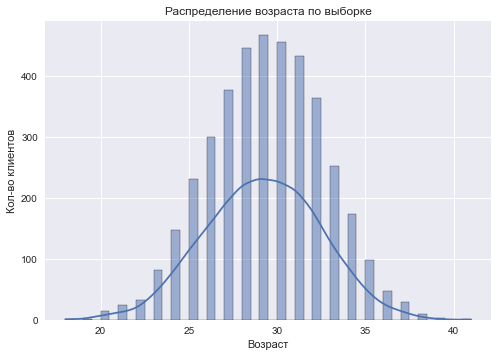

In [10]:
print(df['age'].describe())
sns.histplot(x=df['age'], kde=True)
plt.title('Распределение возраста по выборке')
plt.xlabel('Возраст')
plt.ylabel('Кол-во клиентов')
plt.show()

Возраст клиентов нормально распределен в диапазоне от 18 до 41 года, с пиком в районе 30. Данные выглядят реально, аномалии отсутствуют. 

Для более детального анализа отдельных атрибутов зададим функцию `attribute_research`, выдающую статистическое описание с добавленным 99% перцентилем и комбинированный график, состоящий из гистограммы с оценкой плотности ядра и диаграммы размаха, размещенных на единой оси X.

In [11]:
# функция принимает на вход название датафрейма (data), название колонки с исследуемым атрибутом (attribute)
# и подпись графика (title)
def attribute_research(data, attribute, title):
    print(data[attribute].describe(percentiles=[0.25, 0.75, 0.99]))
    fig_num, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': (.1, .9)}, figsize=(10, 7))
    plt.title(title)
    sns.boxplot(x=data[attribute], ax=ax_box)
    sns.histplot(x=data[attribute], ax=ax_hist, kde=True)
    plt.minorticks_on()
    plt.grid(which='minor', linestyle=':')

Применим функцию attribute_research для изучения срока жизни клиентов.

count    4000.000000
mean        3.724750
std         3.749267
min         0.000000
25%         1.000000
50%         3.000000
75%         5.000000
99%        17.000000
max        31.000000
Name: lifetime, dtype: float64


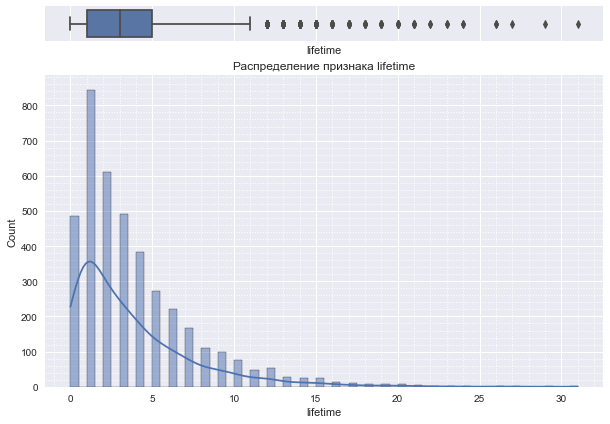

In [12]:
attribute_research(df, 'lifetime', 'Распределение признака lifetime')

Медианный клиент по выборке заключил договор с сетью 3 месяца назад, а пик приходится на 1 месяц, в целом распределение сильно усечено в сторону новых клиентов. Стандартное отклонение практически в точности совпадает со средним значением. При этом в выборке имеются клиенты с лайфтаймом почти 3 года, тогда как 99% перцентиль ограничивается 17 месяцами.

count    4000.000000
mean      146.943728
std        96.355602
min         0.148205
25%        68.868830
50%       136.220159
75%       210.949625
99%       400.996125
max       552.590740
Name: avg_additional_charges_total, dtype: float64


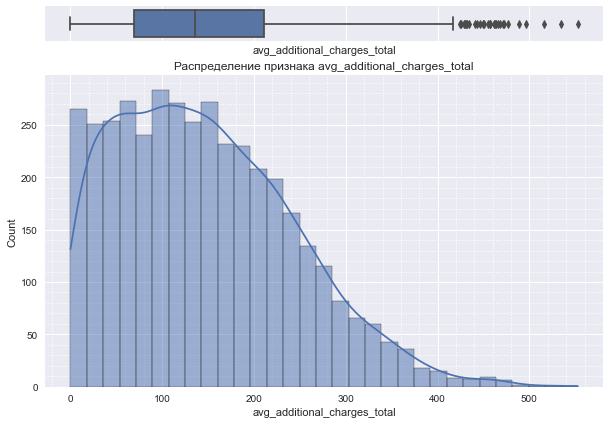

In [13]:
attribute_research(df, 'avg_additional_charges_total', 'Распределение признака avg_additional_charges_total')

Распределение суммарной выручки от дополнительных услуг сильно усечено слева, с плато в диапазоне от 0 до 200, далее плавно снижается. Максимальное значение примерно на 38% выше 99% перцентиля, за счет этого среднее немного выше медианы. Стандартное отклонение в 1,5 раза меньше среднего. В целом, данные достаточно однородные, явные аномалии отсутствуют.

count    4000.000000
mean        1.879020
std         0.972245
min         0.000000
25%         1.180875
50%         1.832768
75%         2.536078
99%         4.197579
max         6.023668
Name: avg_class_frequency_total, dtype: float64


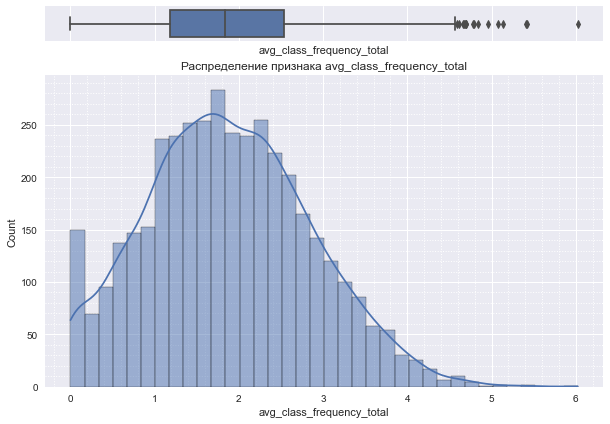

In [14]:
attribute_research(df, 'avg_class_frequency_total', 'Распределение признака avg_class_frequency_total')

Распределение средней частоты посещений в неделю за все время с начала действия абонемента клиента имеет форму нормального распределения, усеченного слева и скошенного вправо, с локальным изолированным пиком в районе нуля. Хотя в наборе присутствуют аномальные клиенты, мотивированные атлеты, тренирующиеся 5 и более раз в неделю, их количество невелико, а сами аномальные показатели, в силу ограниченности количества дней недели, не слишком сильно отличаются от типовых значений выборки, поэтому среднее и медиана идентичны.

count    4000.000000
mean        1.767052
std         1.052906
min         0.000000
25%         0.963003
50%         1.719574
75%         2.510336
99%         4.185758
max         6.146783
Name: avg_class_frequency_current_month, dtype: float64


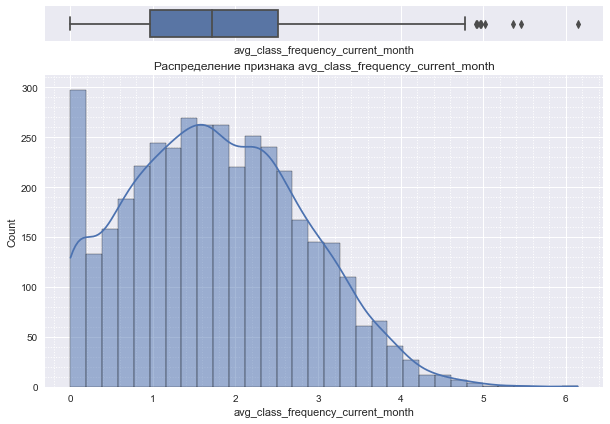

In [15]:
attribute_research(df, 'avg_class_frequency_current_month', 'Распределение признака avg_class_frequency_current_month')

Распределение средней частоты посещений в неделю за последний месяц похоже на распределение атрибута avg_class_frequency_total, однако скошено сильнее. Также в глаза бросается пик распределения в районе нуля. Судя по графикам распределений этих признаков, новые пользователи чаще попадают в отток, поэтому пик в районе нуля сглажен на полных данных о средней частоте посещений, а в данных за последний месяц, наоборот, ярче выражен.

Посмотрим на средние значения признаков в двух группах — тех, кто ушел в отток и тех, кто остался.

In [16]:
cr_mean_features = df.groupby('churn').mean().T
cr_mean_features['ratio'] = 1 - (cr_mean_features[0] / cr_mean_features[1])
cr_mean_features

churn,0,1,ratio
gender,0.510037,0.510839,0.001569
near_location,0.873086,0.768143,-0.136619
partner,0.534195,0.355325,-0.503398
promo_friends,0.353522,0.183789,-0.923520
phone,0.903709,0.902922,-0.000872
contract_period,5.747193,1.728558,-2.324848
group_visits,0.464103,0.268615,-0.727768
age,29.976523,26.989632,-0.110668
avg_additional_charges_total,158.445715,115.082899,-0.376796
month_to_end_contract,5.283089,1.662582,-2.177641


Обращает на себя внимание, что среди пользователей, попавших в отток, средние значения всех признаков, кроме пола, меньше. Распределение пола клиентов и факта наличия контактного телефона практически идентично. Признаков, средние значения которых отличаются незначительно, всего два (near_location и age). Также присутствуют признаки, у которых среднее значение между группами отличается разы (contract_period, month_to_end_contract и lifetime), вероятно они оказывают сильное влияние на факт оттока. Отличие средних значений оставшихся 7 признаков лежит в диапазоне от 37 до 94%.

Построим столбчатые диаграммы с распределением признаков с количеством допустимых значений не более трех и гистограммы для прочих, в разрезе тех, кто ушёл (отток) и тех, кто остался (не попали в отток). Для этого зададим функцию distribution_of_the_target_attribute, которая принимает на вход название таблицы и бинарной целевой переменной из нее.

In [17]:
def distribution_of_the_target_attribute(data, target_attribute):
    bar_attribute_list = []
    hist_attribute_list = []
    if data[target_attribute].nunique() == 2:
        ta_first_value = data[target_attribute].unique()[0]
        ta_second_value = data[target_attribute].unique()[1]
    else:
        return print('Ошибка. Целевая переменная не является бинарной')
    
    for column in data.columns:
        if data[column].nunique() <= 4 and column != target_attribute:
            bar_attribute_list.append(column)
        elif data[column].nunique() > 4 and column != target_attribute:
            hist_attribute_list.append(column)
            
    for attribute in bar_attribute_list:
        s1 = data[data[target_attribute] == ta_first_value].groupby(attribute)[target_attribute].count()
        s2 = data[data[target_attribute] == ta_second_value].groupby(attribute)[target_attribute].count()
        att_fig = pd.concat([s1, s2], axis=1)
        att_fig.columns=['{}={}'.format(target_attribute, ta_first_value), '{}={}'.format(target_attribute, ta_second_value)]
        att_fig.T.plot(kind='bar', title=attribute)
        plt.xticks(rotation='horizontal')
        plt.show()
            
    for attribute in hist_attribute_list:
        fig_sup, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5), gridspec_kw={'width_ratios': (.5, .5)})
        plt.suptitle('{}'.format(attribute), fontsize=17)
        if data[data[target_attribute] == ta_first_value][attribute].nunique() >= 20:
            att_bins = 20
        else:
            att_bins = data[data[target_attribute] == ta_first_value][attribute].nunique()
        data[data[target_attribute] == ta_first_value][attribute].plot(
            kind='hist', bins=att_bins, title='{}: {}'.format(target_attribute, ta_first_value), ax=axs[0])
        if data[data[target_attribute] == ta_second_value][attribute].nunique() >= 20:
            att_bins = 20
        else:
            att_bins = data[data[target_attribute] == ta_second_value][attribute].nunique()
        data[data[target_attribute] == ta_second_value][attribute].plot(
            kind='hist', bins=att_bins, title='{}: {}'.format(target_attribute, ta_second_value), color='orange', ax=axs[1])
        plt.show()

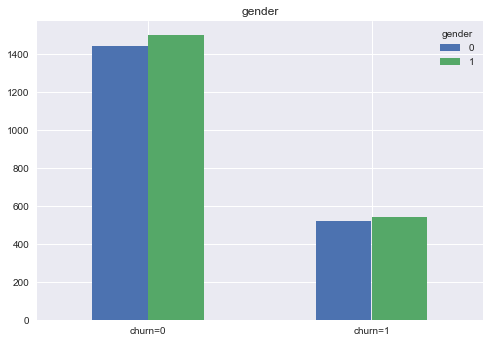

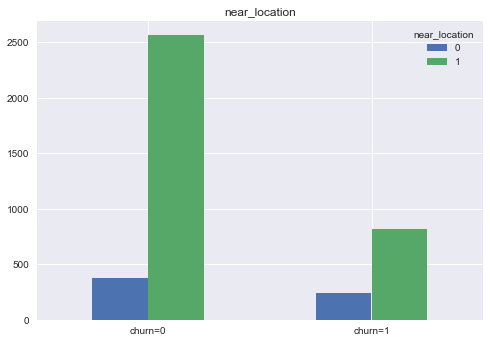

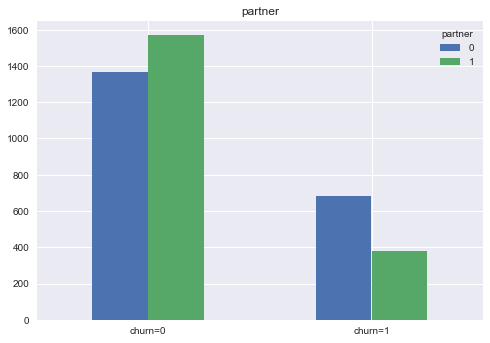

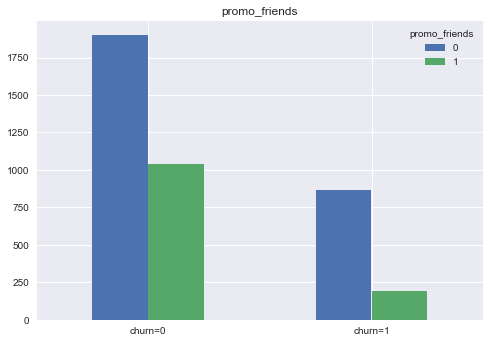

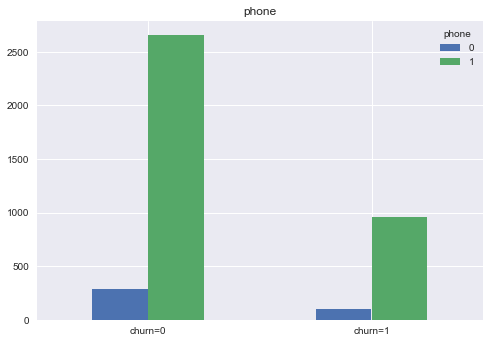

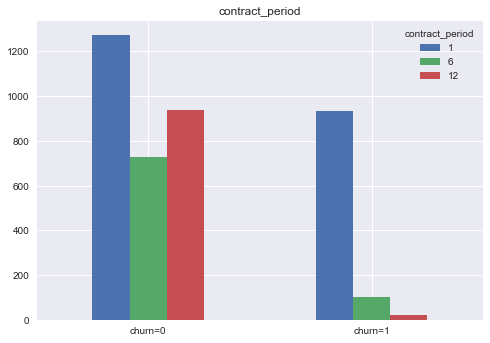

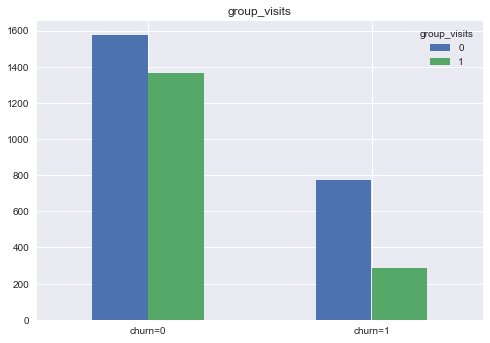

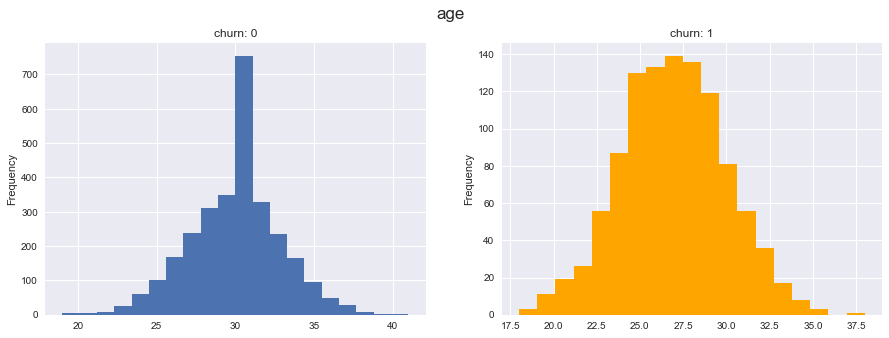

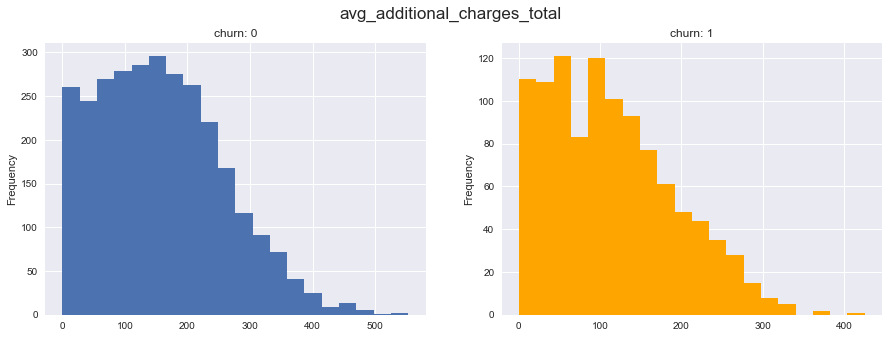

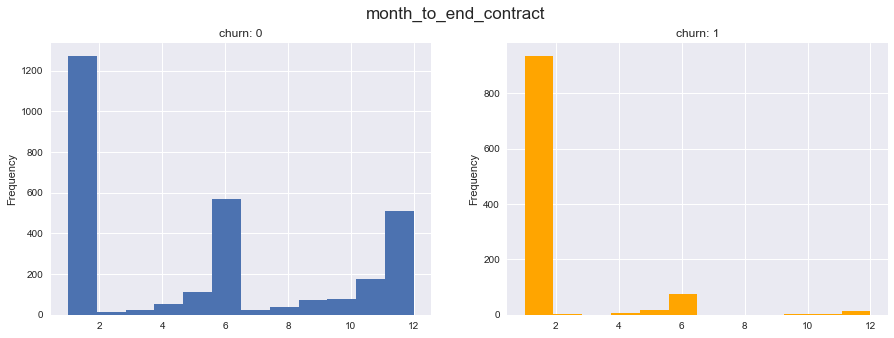

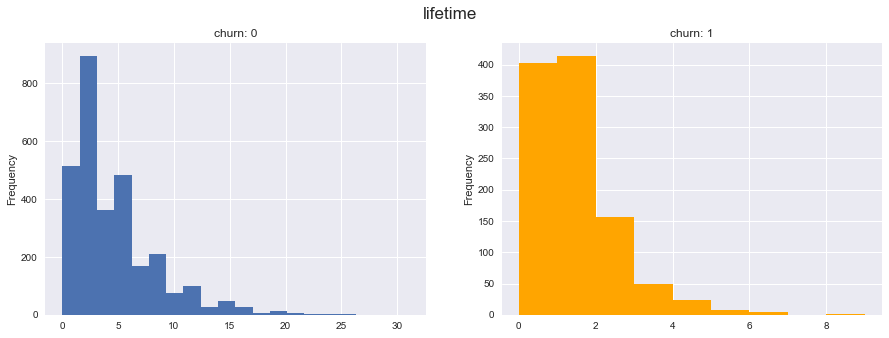

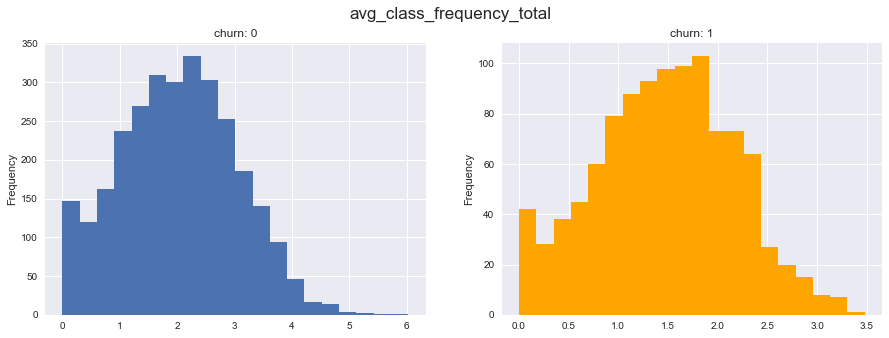

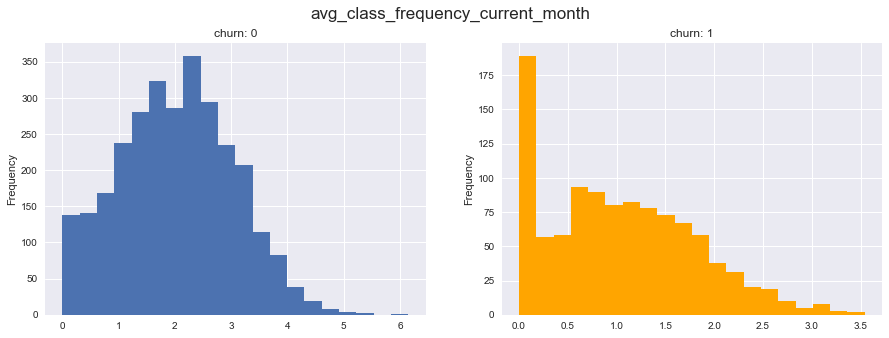

In [18]:
distribution_of_the_target_attribute(df, 'churn')

Распределение большей части признаков имеет отличия, некоторые из них - значимые. Вкратце пройдем по всем:
- распределение по полу практически не отличается, очевидно данный признак оказывает слабое влияние на целевую переменную;
- распределение near_location уже существенно отличается, среди оставшихся клиентов больше доля проживающих или работающих в районе расположения фитнес-центра;
- среди ушедших клиентов большинство не являются сотрудниками компаний-партнеров, тогда как у не попавших в отток наоборот;
- доля пришедших в рамках акции клиентов среди попавших в отток ниже, чем у оставшихся, вероятно наличие друзей, с которыми можно ходить на тренировки уменьшает вероятность, что человек их бросит;
- наличие контактного телефона не оказывает какого-либо заметного влияния на целевую переменную;
- а вот срок, на который оформляется абонемент, напротив, оказывает на целевую переменную огромное влияние - если абонемент оформлен на 1 месяц, шанс того, что человек этим месяцем и ограничится очень велик;
- факт посещения групповых занятий значимо влияет на вероятность оттока - если клиент их посещал, вероятность его ухода меньше;
- форма распределения возраста попавших и нет в отток отличается очень сильно: у оставшихся пользователей ярко выражен пик в районе 31 года, форма распределения нормальная, тогда как у ушедших в отток выраженный пик отсутствует, зато форма графика более вытянутая, что свидетельствует о более низком стандартном отклонении - возраст ушедших пользователей распределен менее равномерно и достаточно плотно сгруппирован вокруг значения 28 лет;
- форма распределения суммарной выручки от других услуг фитнес-центра схожа, однако у ушедших график смещен по оси X влево - не ушедшие в отток клиенты тратят примерно на 100 единиц больше;
- гистограммы срока до окончания действия абонемента (month_to_end_contract) сильно напоминают графики распределения срока оформляемого абоненмента (contract_period): у подавляющей части ушедших в отток клиентов оставаляс 1 месяц до конца абонемента, остальных значений несопоставимо меньше;
- распределение лайфтайма ушедших в отток клиентов сильно смещено по оси X, практически все пользователи сконцентрированы в диапазоне до 3 месяцев, тогда как распределение оставшихся более равномерно;
- аналогино распределена средняя частота посещений - график ушедших сжат по оси X практически вдвое, оставшиеся пользователи посещают фитнес-центр заметно чаще;
- тоже самое можно сказать и про среднюю частоту посещений за предыдущий месяцЮ, за исключением того, что у ушедших в отток бросается в глаза пика на нуле.

Таким образом можно выделить несколько признаков, которые, вероятно, практически не влияют на отток (age, phone), а также такие, что влияют на него очень сильно (lifetime, month_to_end_contract и contract_period). Остальные признаки, очевидно, оказывают менее выраженное влияние, но пренебрегать им нельзя.

Перед построением матрицы корреляции признаков избавимся от выбросов в признаках с неограниченным диапазоном значений (avg_additional_charges_total, lifetime avg_class_frequency_total и avg_class_frequency_current_month). Заменим все значения, выходящие за 99% перцентиль на него же.

In [19]:
for col in ['avg_additional_charges_total', 'lifetime', 'avg_class_frequency_total', 'avg_class_frequency_current_month']:
    df[col] = df[col].where(df[col] < np.percentile(df[col], 99), np.percentile(df[col], 99))

Построим матрицу корреляций признаков.

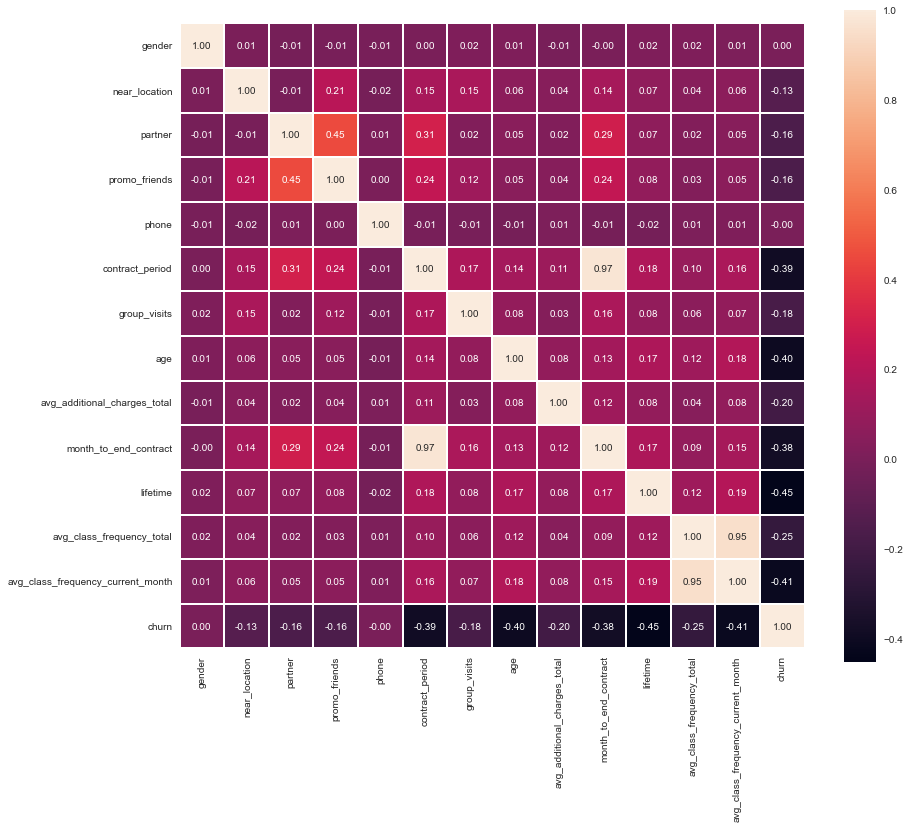

In [20]:
cm = df.corr()
plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=True, square=True, fmt='.2f', linewidths=0.1)
plt.show()

В данных есть две пары признаков, показывающих черезвычайно высокую, близкую к единице, корреляцию - это contract_period/month_to_end_contract и avg_class_frequency_total/avg_class_frequency_current_month. Для того, чтобы избежать потенциального негативного влияния мультиколлинеарности на модели машинного обучения, которые будут использоваться, оставим по одноу признаку из каждой выявленной пары. Т.к. avg_class_frequency_current_month показывает значительно более сильную корреляцию с целевой переменной, оставим именно его, а от признака avg_class_frequency_total избавимся. Из второй пары оставим признак contract_period, т.к. его можно сразу применять при оценке новых клиентов, а уровень корреляции с целевой метрикой у рассматриваемой пары идентичен. Остальные признаки слабо коррелируют как между собой, так и с целевой переменной - самый высокий коэффициет корреляции как между признаками, так и с целевой переменной - 0,45.

In [21]:
df = df.drop(columns=['avg_class_frequency_total', 'month_to_end_contract'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   near_location                      4000 non-null   int64  
 2   partner                            4000 non-null   int64  
 3   promo_friends                      4000 non-null   int64  
 4   phone                              4000 non-null   int64  
 5   contract_period                    4000 non-null   int64  
 6   group_visits                       4000 non-null   int64  
 7   age                                4000 non-null   int64  
 8   avg_additional_charges_total       4000 non-null   float64
 9   lifetime                           4000 non-null   float64
 10  avg_class_frequency_current_month  4000 non-null   float64
 11  churn                              4000 non-null   int64

Исследовательский анализ данных завершен, приступим к построению модели прогнозирования оттока клиентов.

## Построение модели прогнозирования оттока клиентов

Построим модель бинарной классификации клиентов, где целевой признак — факт оттока клиента в следующем месяце, и обучим её с применением двух алгоритмов - логистической регрессии и случайного леса. Для этого Разделим таблицу df на признаки (матрица X) и целевую переменную (вектор y) в пропорции 80/20. Так как в имеющихся данных нет привязки ко времени, будем использовать случайное деление выборки на обучающую (X_train, y_train) и валидационную (X_test, y_test). Т.к. соотношение классов в целевой переменной по выборке примерно 1 к 4, стратифицируем разбиение в соответствии с распределением по классам в целевой переменной (y). Cтандартизацю данных проводить не будем, в применяемых моделях она не обязательна.

In [22]:
X = df.drop('churn', axis=1)
y = df['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

Далее зададим функцию `make_prediction`, которая принимает на вход модель с заданными параметрами (mod), а также матрицы признаков и векторы с целевой переменной из обучающей (X_train, y_train) и валидационной выборок (X_test, y_test). Возвращает функция значения метрик accuracy, precision, recall и ROC AUC, полученных на валидационной выборке.

In [23]:
def make_prediction(mod, X_train, y_train, X_test, y_test):
    model = mod
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]
    print(
        'accuracy:{:.2f}; precision:{:.2f}; recall:{:.2f}; ROC AUC:{:.2f}'.format(
            accuracy_score(y_test, predictions),
            precision_score(y_test, predictions),
            recall_score(y_test, predictions),
            roc_auc_score(y_test, probabilities)
        )
    )

Применим функцию make_prediction и обучим модель алгоритмом логистической регрессии.

In [24]:
make_prediction(LogisticRegression(solver='liblinear', random_state=0), X_train, y_train, X_test, y_test)

accuracy:0.91; precision:0.85; recall:0.82; ROC AUC:0.97


Метрики получились вполне достойные, однако попробуем немного улучшить результат путем подбора параметра C у логистической регрессии.

In [25]:
make_prediction(LogisticRegressionCV(solver='liblinear', random_state=0), X_train, y_train, X_test, y_test)

accuracy:0.92; precision:0.85; recall:0.84; ROC AUC:0.97


Доля правильных ответов и полнота немного улучшились. Теперь обучим модель алгоритмом случайного леса, установив параметр количества решающих деревеьв равным 300.

In [26]:
make_prediction(RandomForestClassifier(n_estimators = 300, random_state = 0), X_train, y_train, X_test, y_test)

accuracy:0.91; precision:0.86; recall:0.80; ROC AUC:0.96


Значения метрик, в целом, близки к логистической регрессии, однако у случайного леса метрика полноты ниже сразу на 4 процентных пункта. Попробуем улучшить метрики путем подбора основных не заданных параметров модели: max_depth, min_samples_leaf, min_samples_split.

In [27]:
parametrs = { 'max_depth': range (1, 13, 2),
              'min_samples_leaf': range (1, 8),
              'min_samples_split': range (2, 10, 2) }
clf = RandomForestClassifier()
grid = GridSearchCV(clf, parametrs, cv=5)
grid.fit(X_train, y_train)
grid.best_params_

{'max_depth': 9, 'min_samples_leaf': 2, 'min_samples_split': 2}

In [28]:
make_prediction(RandomForestClassifier(n_estimators = 300, max_depth = 11, min_samples_leaf = 1,
                                       min_samples_split = 6, random_state = 0), X_train, y_train, X_test, y_test)

accuracy:0.92; precision:0.87; recall:0.81; ROC AUC:0.96


Все метрики, кроме ROC AUC, улучшились на 1 процентный пункт. Теперь попробуем модель градиентного бустинга, количество деревьев - 300.

In [29]:
make_prediction(GradientBoostingClassifier(n_estimators = 300, random_state = 0), X_train, y_train, X_test, y_test)

accuracy:0.92; precision:0.85; recall:0.83; ROC AUC:0.96


Точность на 2 процента ниже, полнота на 2 процента выше чем у случайного леса. В итоге все модели показали близкие результаты, однако логистическая регрессия по совокупности метрик оказалась лучшей. Учитывая это, а также лучшую интерпритируемость моделей регрессии, нежели ансамблей, рациональнее остановиться именно на ней. Выедем коэффициенты, присвоеные моделью признакам, а также значение нулевого коэффициента. Однако учитывая значительный разброс возможного диапазона значений у различных признаков, для упрощения интерпритирования коэффициентов полученных моделью предварительно выполним нормализацию значений признаков.

In [30]:
from sklearn.preprocessing import MinMaxScaler
trans = MinMaxScaler()
X_trans = trans.fit_transform(df.drop('churn', axis=1))
X_train_tr, X_test_tr, y_train, y_test = train_test_split(X_trans, y, test_size=0.2, stratify=y, random_state=0)
model_tr = LogisticRegressionCV(solver='liblinear', random_state=0)
model_tr.fit(X_train_tr, y_train)
print(pd.Series(data=model_tr.coef_[0], index=df.drop('churn', axis=1).columns).sort_values())
model_tr.intercept_

lifetime                            -16.608853
age                                  -8.117072
avg_class_frequency_current_month    -5.112235
contract_period                      -3.429624
avg_additional_charges_total         -2.360018
group_visits                         -0.776155
promo_friends                        -0.333738
phone                                -0.239039
near_location                        -0.164383
partner                              -0.106026
gender                                0.053909
dtype: float64


array([8.75555208])

При помощи модели можно выделить 5 основных признаков, максимально влияющих на вероятность оттока: lifetime, avg_class_frequency_current_month, contract_period, avg_additional_charges_total и, неожиданно, age. Причем по значению модуля коэффициента возраст оказался на втором месте среди всех признаков. Максимальное влияние оказывает lifetime, замыкает пятерку avg_additional_charges_total. Влияние остальных признаков несущественно - сумма модулей их коэффициентов вместевзятых меньше замыкающего вышеописанную пятерку признака. Проверим как нормализация данных отразилась на точности модели.

In [31]:
make_prediction(LogisticRegressionCV(solver='liblinear', random_state=0), X_train_tr, y_train, X_test_tr, y_test)

accuracy:0.92; precision:0.85; recall:0.84; ROC AUC:0.97


После нормализации метрики модели не изменились, можно пробовать использовать эту модель на реальных данных в следующем месяце.

## Кластеризация клиентов

Проведем кластеризацию клиентов сети. Так как для моделей кластеризации крайне важна стандартизация данных, предварительно проведем её.

In [32]:
scaler = StandardScaler()
X_st = scaler.fit_transform(X)

На стандартизованной матрице признаков построим матрицу расстояний функцией linkage() и выведем дендрограмму.

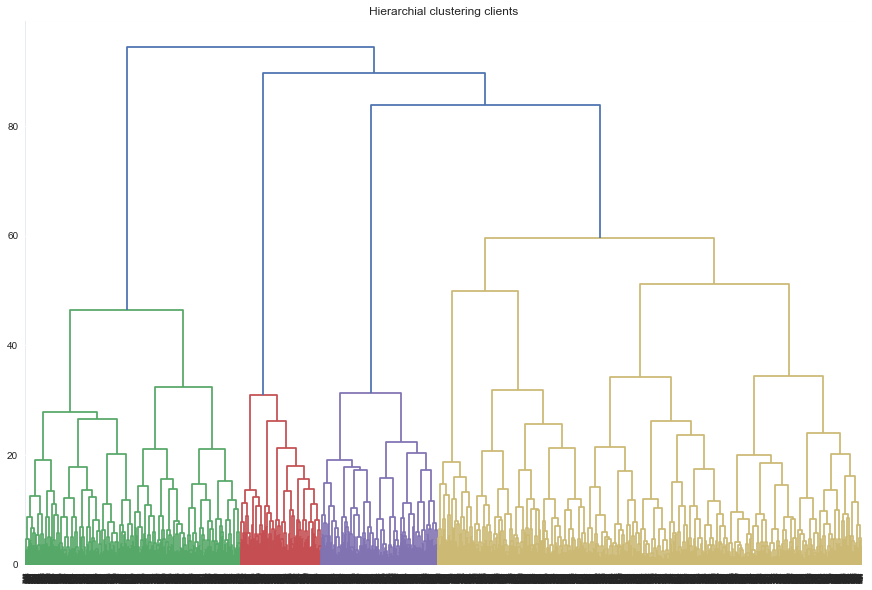

In [33]:
linked = linkage(X_st, method = 'ward')
plt.figure(figsize=(15, 10))  
dendrogram(linked, orientation='top')
plt.title('Hierarchial clustering clients')
plt.show() 

На дендрограмме выделяется 4 крупных кластера, при этом самый большой охватывает приблизительно половину клиентов, поэтому целесообразно разделить его еще на два. Учитывая небольшой размер исходной выборки не имеет смысл делить клиентов на большее количество кластеров, поэтому обучим модель кластеризации на основании алгоритма K-Means с разделением клиентов на 5 кластеров.

In [34]:
km = KMeans(n_clusters=5, random_state=0)
labels = km.fit_predict(X_st)
df['cluster'] = labels

Посмотрим как модель разбила клиентов на кластеры, а также средние значения признаков для них.

In [35]:
print(df['cluster'].value_counts(normalize=True) * 100)
df.groupby('cluster').mean()

3    26.125
1    25.550
2    24.725
0    13.950
4     9.650
Name: cluster, dtype: float64


,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,lifetime,avg_class_frequency_current_month,churn
cluster,,,,,,,,,,,,
0,0.500000,0.000000,0.489247,0.078853,1.0,2.994624,0.232975,28.679211,136.371956,2.956989,1.593631,0.403226
1,0.545010,0.996086,0.384540,0.007828,1.0,6.100783,0.512720,30.589041,176.758872,5.314090,2.340562,0.016634
2,0.496461,0.995956,0.887765,1.000000,1.0,6.898888,0.524772,29.600607,153.607876,4.290192,1.913650,0.118301
3,0.489952,1.000000,0.211483,0.071770,1.0,2.059330,0.297608,27.644019,116.510463,1.839234,1.160055,0.573206
4,0.523316,0.862694,0.471503,0.305699,0.0,4.777202,0.427461,29.297927,143.798208,3.888601,1.721357,0.266839


Если рассматривать кластеры с точки зрения распределения целевого признака - один кластер имеет долю клиентов ушедших в отток практически равную среднему по всей выборке (26,7%), два с низкой (1,7 и 11,8 процентов) и два с выской (40 и 57 процентов) вероятностью оттока клиентов. При этом выделяется два признака, среднее значение которых отличается слабым разбросом по всем кластерам - пол и возраст. Охарактеризуем кластеры более подробно:
1. Кластер со средним процентом оттока (под номером 4) самый малочисленный (менее 10%) и в целом практически точно повторяет средние значения всех признаков - вероятно в нем собраны "усредненные" клиенты. Что любопытно, значение признака наличия телефона равно нулю, а значение в прочих кластерах равно единице, т.е. в данном кластере собраны абсолютно все клиенты из выборки, не указавшие телефон.
2. Кластеры с низким процентом оттока (1 и 2) имеют более высокие средние значения всех пяти признаков, выделенные моделью прогнозирования оттока. Однако кластер с минимальным количеством ушедших пользователей (номер 1) имеет крайне низкое значение признака promo_friends. Практически все клиенты (99,6%) из этих кластеров живут или работают около фитнес-центров. В сумме в эти кластеры входит половина клиентов. 
3. Кластеры с высоким процентом оттока (0 и 3) имеют минимальные значения признаков contract_period, group_visits, age, avg_additional_charges_total, lifetime и avg_class_frequency_current_month. Причем если значения признаков age и avg_additional_charges_total отличаются от кластеров с низким процентом оттока незначительно как в абсолютном, так и относительном выражении, то contract_period, group_visits и lifetime отличаются существенно - часто в разы. Любопытно отметить, что кластер с номером 0 маленький по размеру и полностью состоит из пользователей, проживающих или работающих вне района нахождения фитнес-центров.

Визуализируем распределение признаков для кластеров. Для этого зададим функцию `distribute_attributes_in_clusters`, принимающую на вход название датафрейма и колонки с названиями кластеров.

In [36]:
def distribute_attributes_in_clusters(data, cluster_column):
    cluster_cnt = data[cluster_column].nunique()
    bar_attribute_list = []
    hist_attribute_list = []
    for column in data.columns:
        if data[column].nunique() <= 4 and column != cluster_column:
            bar_attribute_list.append(column)
        elif data[column].nunique() > 4 and column != cluster_column:
            hist_attribute_list.append(column)
            
    data = data.reset_index()
    for attribute in bar_attribute_list:
        data.pivot_table(
            index=attribute, columns=cluster_column, values='index', aggfunc='count').T.plot(kind='bar', title=attribute)
        plt.xticks(rotation='horizontal')
        plt.show()
    data.drop(columns='index', inplace=True)
            
    for attribute in hist_attribute_list:
        fig_sup, axes = plt.subplots(nrows=math.ceil(cluster_cnt/3), ncols=3, figsize=(16, (5*math.ceil(cluster_cnt/3))))
        plt.suptitle('{}'.format(attribute), fontsize=17)
        axs = axes.ravel()
        for cluster in data[cluster_column].unique():
            if data[data[cluster_column] == cluster][attribute].nunique() >= 20:
                att_bins = 20
            else:
                att_bins = data[data[cluster_column] == cluster][attribute].nunique()
            data[data[cluster_column] == cluster][attribute].plot(
                kind='hist', bins=att_bins, title='{}: {}'.format(cluster_column, cluster), ax=axs[cluster])
        plt.show()

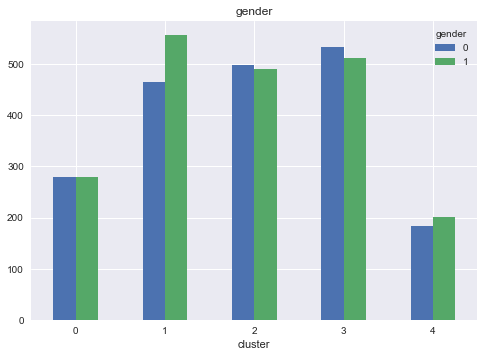

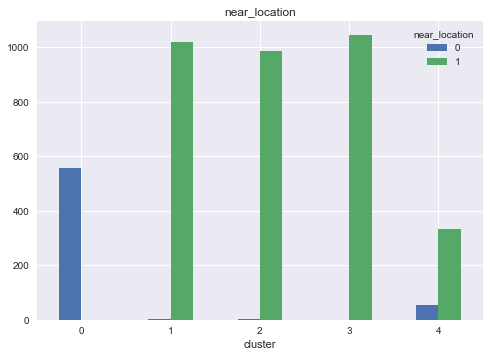

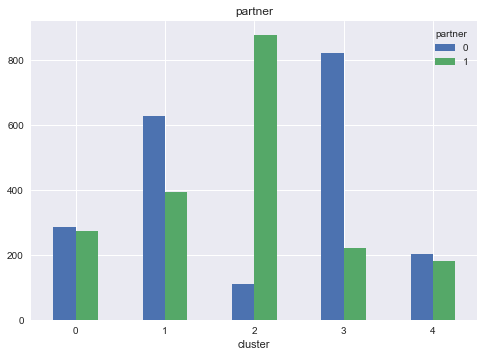

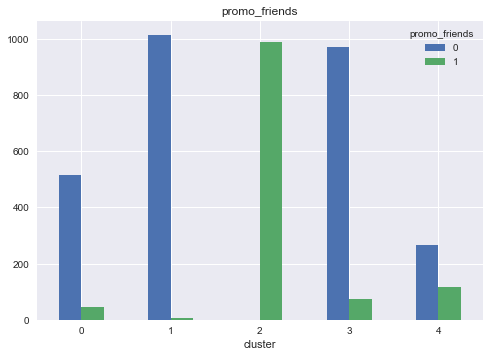

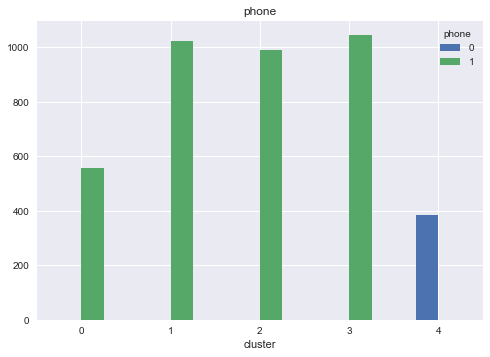

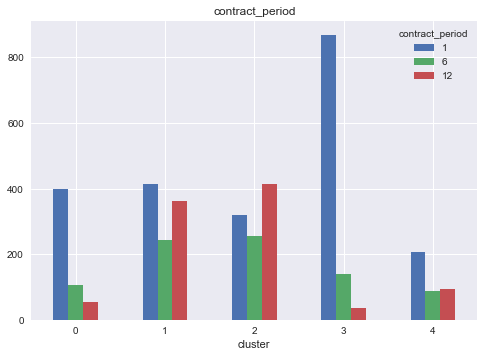

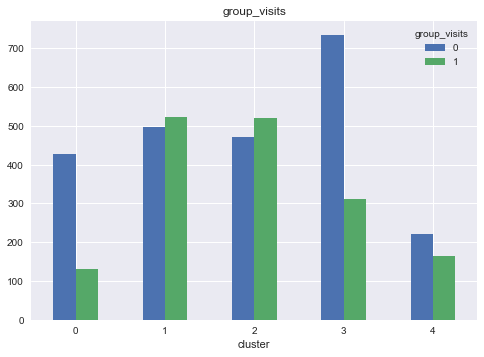

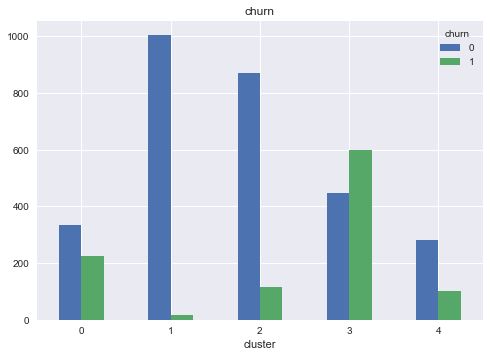

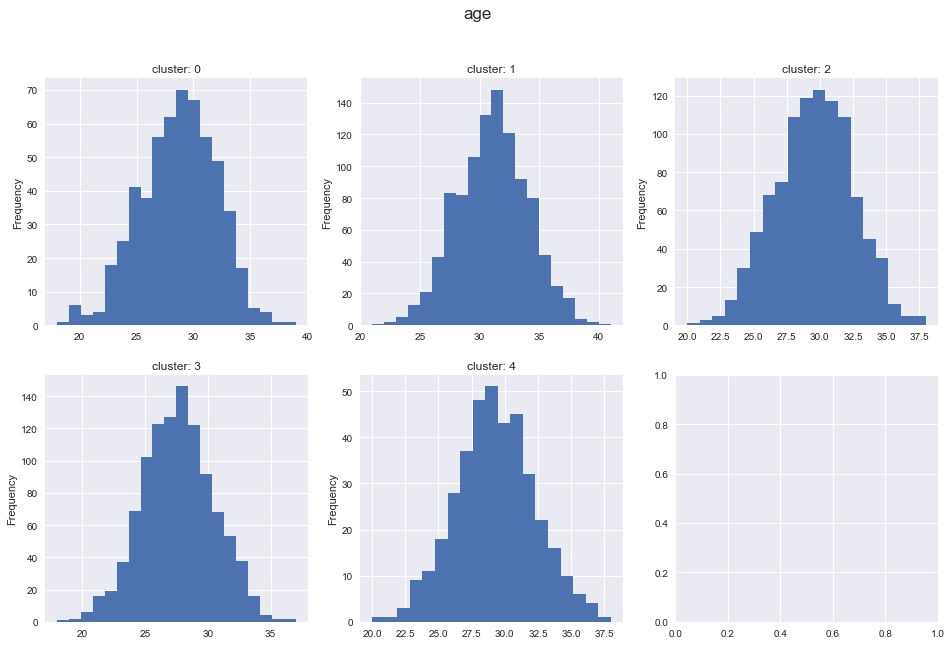

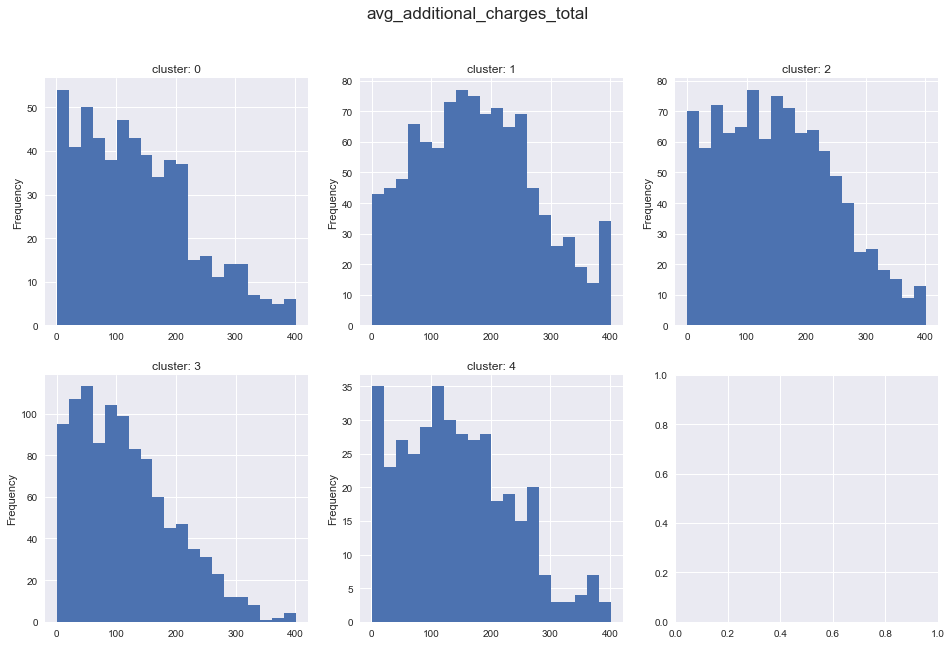

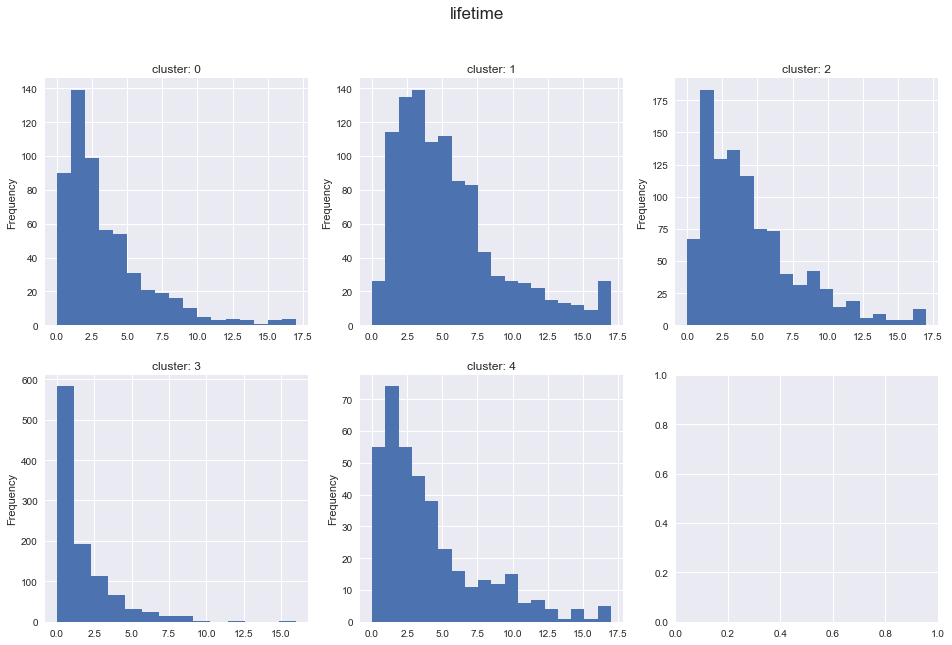

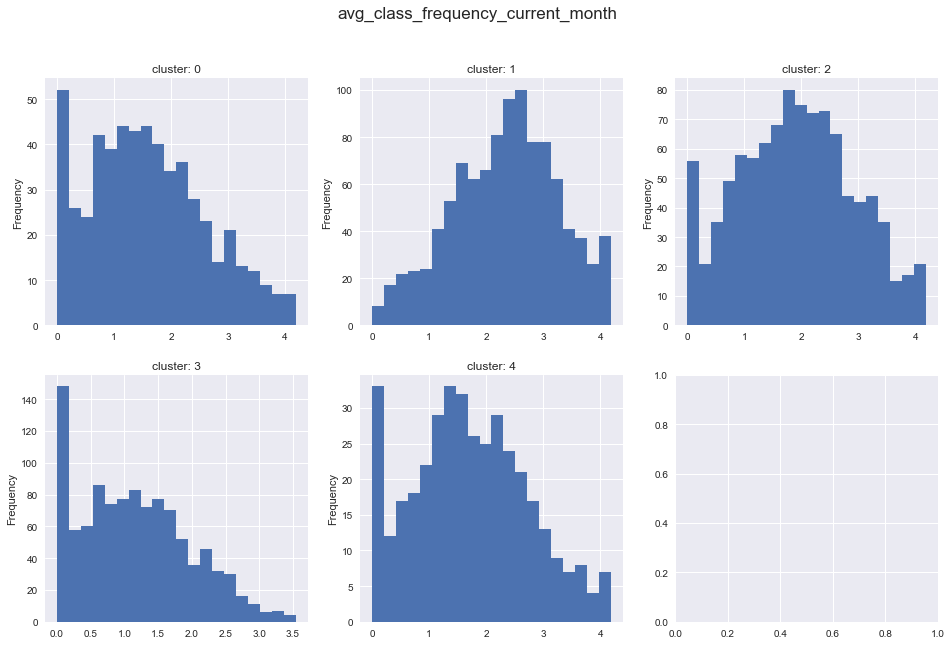

In [37]:
distribute_attributes_in_clusters(df, 'cluster')

Распределение бинарных признаков по кластерам нет смысла рассматривать подробно - оно было понятно при анализе средних значений таких признаков. А вот на небинарных остановимся подробнее:
- в распределении длительности абоненмента месячный вариант доминирует во всех кластерах, кроме 2: в нем собраны клиенты с большой длительностью абоненментов, c пиком на 12 месяцах;
- распределение значений возраста имеет форму нормального по всем кластерам, однако смещается по оси X, в кластере с максимальным оттоком возраст смещен максимально влево, в кластере с минимальным напротив вправо;
- форма распределения суммарной выручки от других услуг фитнес-центра довольно сильно отличается от кластера к кластеру, однако по кластерам с минимальным и максимальным значением целевой переменной ситуация анологична возрасту - в группе в наивысшим оттток распределение смещено к началу оси, с наиболее низким - вправо, к большим величинам;
- аналогичная ситуация и с лайфтаймом - чем выше отток, тем сильнее распределение прижимается к началу оси;
- форма распределения средней частоты посещения за последний месяц сильно отличается у разных кластеров, но общее правило неизменно - чем выше отток в кластере, тем сильнее распределение прижимается к началу оси X.

В целом можно заметить, что форма распределения признаков у кластера 0 очень схожа с распределением этих же признаков у совокупной выборки. Распределение в остальных кластерах вполне характеризуется средними значениями. Форма распределения значений признаков соотносится с процентом оттока в кластерах и влиянием на него соответствующих признаков.

## Выводы и базовые рекомендации по работе с клиентами

Перед написанием выводов и рекомендаций проверим одну гипотезу - среди клиентов оформивших абонемент на срок более месяца и посещающих групповые тренировки процент оттока крайне мал. В том числе среди клиентов, не живущих или работающих в районе расположения клуба.

In [38]:
round(df.query('group_visits == 1 and contract_period != 1')['churn'].mean() * 100, 2)

4.38

In [39]:
round(df.query('cluster == 0 and group_visits == 1 and contract_period != 1')['churn'].mean() * 100, 2)

7.55

Гипотеза подтвердилась - сочетание длительного абоненмента и групповых занятий радикально снижает процент оттока в рассмотренных группах клиентов. Перейдем к выводам.

Клиентов сети можно поделить на 5 групп. Также после описания приведены специфические рекомендации по работе с конкретной группой.
1. **Кластер с номером 4.** Средние по всем параметрам, ничем не выделяющиеся клиенты, вероятность уйти в отток - около 25%. Таких не много, всего около 10%.
2. **Кластер с номером 1.** Максимально лояльная (отток меньше 2%), самая возрастная и довольно многочисленная (примерно четверть) группа клиентов. Живут или работают в районе нахождения фитнес-центов, приняли решение ходить самостоятельно (менее 1% пришло по промо-акции "приведи друга"). Имеют макимальный лайф-тайм, среднюю частоту посещений в месяц и траты на сопутствующие услуги. Процент сотрудников компаний-партнёров клуба относительно невелик, похоже, что это мотивированные заниматься спортом люди, посещающие наиболее устраивающий клуб в их районе проживания/работы. Самые ценные клиенты, но вряд ли данный кластер можно серьезно увеличить с помощью маркетинга.
3. **Кластер с номером 2.** Многочисленная (четверть) группа клиентов с высокой лояльностью (процент оттока 12%, более чем вдвое ниже среднего). Также как и клиенты из первого кластера живут/работают в районе клуба и часто оформляют абонемент на длительные сроки. Ключевым отличием является то, что абсолютно все они пришли по промо-акции и почти 90% являются сотрудниками компаний-партнёров клуба. Чаще покупают абонемент с максимальным сроком, вероятно по привлекательной партнерской цене. Чаще всего ходят на групповые тренировки, и в целом часто посещают занятия, довольно много тратят на дополнительные услуги. Возможно расширять базу клиентов из этой группы, заключая партнерские соглашения с новыми компаниями.
4. **Кластер с номером 3.** Самый многочисленный и проблемный кластер - прочти 60% оттока. Характеризуется минимальным возрастом и почти всегда покупкой пробного месячного абонемента. Редко ходят на групповые тренировки и являются сотрудниками партнеров, еще реже приходят по промо-акции. Завершают картину минимальные частота посещений, лайфтайм и траты на доп.услуги.
5. **Кластер с номером 0.** Довольно малочисленная (около 12%) группа с очень высоким оттоком (40%). Ключевая черта - они приезжают в клуб из других районов. Значительная часть (половина) является работниками партнеров клуба, крайне редко приходят по промо-акции. Реже всего ходят на групповые тренировки и  целом редко тренируются. Вероятно это начинающие атлеты, привлеченные условиями партнерской программы, которые если уходят в отток и не забрасывают занятия спортом вообще, уходят в клуб, удобнее расположенный для их посещения. Таких клиентов необходимо стимулировать посещать групповые тренировки, а также давать дополнительные скидки на абонементы большой продолжительности, если человек живет/работает вне района расположения клуба - оформившие длительный абонемент и групповые тренировки клиенты уходят в отток значительно реже.

Универсальными рекомендациями вне зависимости от кластеризации клиентов можно считать:
- запуск промо-акций с покупкой длительных абонементов любой продолжительности, главное свыше 1 месяца: факт покупки длинного абонемента сам по себе радикально уменьшает вероятность оттока - среди всех ушедших клиентов 88% имели месячный абонемент;
- расширение промо-ации "приведи друга" - пришедшие по ней клиенты уходят вдвое реже пришедших самостоятельно;
- промо-акции со скидаками на групповые тренировки;
- смешанный промо-акций, комбинация из нескольких должна давать высокий синергетический эффект и значительно уменьшать вероятность оттока.